In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('studentdata.csv')
print(df.head())

print("Data Shape")
print(df.shape[0])
print(df.shape[1])

print("Data Types")
print(df.info())

print("Statistical Summary")
print(df.describe(include='all'))

print("Missing Values")
print(df.isnull().sum())

#Step 2 preprocessing





   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           3          85         72      Yes           7    Yes
1           1          60         45       No           5     No
2           5          95         88      Yes           8    Yes
3           2          70         55      Yes           6     No
4           4          90         80      Yes           7    Yes
Data Shape
50
6
Data Types
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudyHours  50 non-null     int64 
 1   Attendance  50 non-null     int64 
 2   PastScore   50 non-null     int64 
 3   Internet    50 non-null     object
 4   SleepHours  50 non-null     int64 
 5   Passed      50 non-null     object
dtypes: int64(4), object(2)
memory usage: 2.5+ KB
None
Statistical Summary
        StudyHours  Attendance  PastScore Internet  SleepHours Passed
count    50.0000

In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('studentdata.csv')
print(df.head())

print("Missing Values")
print(df.isnull().sum())

le = LabelEncoder()

df['Internet'] = le.fit_transform(df['Internet'])
df['Passed'] = le.fit_transform(df['Passed'])

print("After Encoding")
print(df.head())

print(df.dtypes)

   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           3          85         72      Yes           7    Yes
1           1          60         45       No           5     No
2           5          95         88      Yes           8    Yes
3           2          70         55      Yes           6     No
4           4          90         80      Yes           7    Yes
Missing Values
StudyHours    0
Attendance    0
PastScore     0
Internet      0
SleepHours    0
Passed        0
dtype: int64
After Encoding
   StudyHours  Attendance  PastScore  Internet  SleepHours  Passed
0           3          85         72         1           7       1
1           1          60         45         0           5       0
2           5          95         88         1           8       1
3           2          70         55         1           6       0
4           4          90         80         1           7       1
StudyHours    int64
Attendance    int64
PastScore     int64
Internet 

   StudyHours  Attendance  PastScore Internet  SleepHours Passed
0           3          85         72      Yes           7    Yes
1           1          60         45       No           5     No
2           5          95         88      Yes           8    Yes
3           2          70         55      Yes           6     No
4           4          90         80      Yes           7    Yes
After Encoding
   StudyHours  Attendance  PastScore  Internet  SleepHours  Passed
0           3          85         72         1           7       1
1           1          60         45         0           5       0
2           5          95         88         1           8       1
3           2          70         55         1           6       0
4           4          90         80         1           7       1
StudyHours    int64
Attendance    int64
PastScore     int64
Internet      int64
SleepHours    int64
Passed        int64
dtype: object
Classification Report
              precision    recall  f1

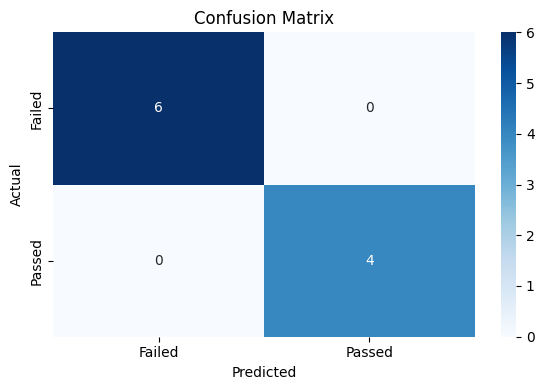

----------------Predict your result--------------
Predicted Result: Passed


d:\ML_bro_let_me_try\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('studentdata.csv')
print(df.head())
le = LabelEncoder()
df['Internet'] = le.fit_transform(df['Internet'])
df['Passed'] = le.fit_transform(df['Passed'])
print("After Encoding")
print(df.head())
print(df.dtypes)

features = ['StudyHours', 'Attendance', 'PastScore', 'SleepHours']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

X = df_scaled[features] #target features
y = df_scaled['Passed'] #target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Failed', 'Passed'], yticklabels=['Failed', 'Passed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("----------------Predict your result--------------")
study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance: "))
past_grades = float(input("Enter Past Grades: "))
sleep_hours = float(input("Enter Sleep Hours: "))

input_data = pd.DataFrame({
    'StudyHours': [study_hours],
    'Attendance': [attendance],
    'PastScore': [past_grades],
    'SleepHours': [sleep_hours]
})

# Scale the input data
input_data_scaled = scaler.transform(input_data)

# Make a prediction
prediction = model.predict(input_data_scaled)[0]

# Decode the prediction
# result = le.inverse_transform(prediction)
result = 'Passed' if prediction == 1 else 'Failed'

print(f"Predicted Result: {result}")